# Boosted-tree tuning and calibration

Notebook 3 established `boosted_numeric` as the winner on all four chronological folds. This notebook tunes that family, keeps `context_C3` as an interpretable comparison model, tests calibration without temporal leakage, and inspects the newest-session failure slices. It does not export a production artifact.

In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 5
TRAIN_ROWS_PER_FOLD = 2_000_000
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
RANDOM_STATE = 42

cache_paths = {s: CACHE_ROOT / f'{s}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for s in SESSION_ORDER}
missing = [str(path) for path in cache_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in cache_paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,383,644 cached rows


## 1. Candidate specification

The boosted candidates vary tree size, learning rate, and L2 regularization around Notebook 3's winning configuration. `logistic_C3` is included as a control, not as the presumed production model. Every learned candidate uses the same deterministic training sample within a fold.

In [2]:
ALL_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]
CONTEXT_CATEGORICAL = ['course_code', 'campus', 'term']
RANK_MONOTONIC = {'position_to_capacity': -1, 'position': -1, 'position_to_waitlist': -1}
LOGISTIC_COLUMNS = ALL_NUMERIC + CONTEXT_CATEGORICAL

def boosted_model(*, learning_rate=0.05, max_iter=200, max_leaf_nodes=15, l2=1.0):
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), ALL_NUMERIC),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=learning_rate, max_iter=max_iter,
            max_leaf_nodes=max_leaf_nodes, l2_regularization=l2,
            random_state=RANDOM_STATE,
            monotonic_cst=[RANK_MONOTONIC.get(feature, 0) for feature in ALL_NUMERIC],
        )),
    ])

def logistic_model():
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value=0)),
                ('scale', StandardScaler()),
            ]), ALL_NUMERIC),
            ('categorical', OneHotEncoder(handle_unknown='ignore', min_frequency=3), CONTEXT_CATEGORICAL),
        ])),
        ('model', LogisticRegression(C=3.0, solver='lbfgs', max_iter=300)),
    ])

CANDIDATES = {
    'boosted_leaf7_l2_1': lambda: boosted_model(max_leaf_nodes=7, l2=1.0),
    'boosted_leaf15_l2_0.3': lambda: boosted_model(max_leaf_nodes=15, l2=0.3),
    'boosted_leaf15_l2_1': lambda: boosted_model(max_leaf_nodes=15, l2=1.0),
    'boosted_leaf15_l2_3': lambda: boosted_model(max_leaf_nodes=15, l2=3.0),
    'boosted_leaf31_l2_1': lambda: boosted_model(max_leaf_nodes=31, l2=1.0),
    'boosted_slow_leaf15': lambda: boosted_model(learning_rate=0.03, max_iter=300, max_leaf_nodes=15, l2=1.0),
    'logistic_C3': logistic_model,
}

def feature_columns(name):
    return LOGISTIC_COLUMNS if name == 'logistic_C3' else ALL_NUMERIC

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    total, error = weight.sum(), 0.0
    for group in range(bins):
        mask = groups == group
        if mask.any():
            observed = np.average(y[mask], weights=weight[mask])
            predicted = np.average(probability[mask], weights=weight[mask])
            error += weight[mask].sum() / total * abs(observed - predicted)
    return float(error)

def metrics(y, probability, weight, reference_probability):
    probability = np.clip(np.asarray(probability), 1e-6, 1 - 1e-6)
    brier = brier_score_loss(y, probability, sample_weight=weight)
    reference = np.full(len(y), reference_probability)
    reference_brier = brier_score_loss(y, reference, sample_weight=weight)
    return {
        'brier': brier, 'brier_skill': 1 - brier / reference_brier,
        'log_loss': log_loss(y, probability, sample_weight=weight, labels=[0, 1]),
        'ece_10': weighted_ece(y, probability, weight),
        'roc_auc': roc_auc_score(y, probability, sample_weight=weight),
    }

print(f'{len(CANDIDATES)} candidates')

7 candidates


## 2. Chronological tuning

The four validation sessions and two-million-row cap match Notebooks 2 and 3. Results checkpoint after each completed fit.

In [3]:
TUNING_PATH = CACHE_ROOT / 'boosted-tuning-canonical-v2.pkl'
tuning_results = pd.read_pickle(TUNING_PATH).to_dict('records') if TUNING_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in tuning_results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=RANDOM_STATE)
    valid = session_samples[valid_session]
    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(train['cleared'], weights=train['model_weight'])
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, factory) in enumerate(CANDIDATES.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(CANDIDATES)}] {name}: fitting', flush=True)
        columns = feature_columns(name)
        model = factory()
        model.fit(model_train[columns], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = model.predict_proba(valid[columns])[:, 1]
        tuning_results.append({
            'validation_session': valid_session, 'candidate': name,
            **metrics(y, probability, weight, reference_probability),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(tuning_results).to_pickle(TUNING_PATH)
        completed.add(key)
        print(f'  complete in {tuning_results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

tuning_scores = pd.DataFrame(tuning_results).sort_values(['validation_session', 'brier'])
tuning_summary = tuning_scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'), mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
display(tuning_summary)
display(tuning_scores.pivot(index='validation_session', columns='candidate', values='brier'))

Fold 20239: 583,644 training rows; 300,000 validation rows


[1/4, 1/7] boosted_leaf7_l2_1: fitting


  complete in 0.0 min


[1/4, 2/7] boosted_leaf15_l2_0.3: fitting


  complete in 0.0 min


...

  complete in 0.2 min


[4/4, 7/7] logistic_C3: fitting


  complete in 0.2 min


,mean_brier,worst_brier,mean_skill,mean_log_loss,mean_ece,mean_auc,total_minutes
candidate,,,,,,,
boosted_leaf15_l2_1,0.051058,0.055246,0.483614,0.172376,0.017339,0.944133,0.383796
boosted_slow_leaf15,0.051073,0.055286,0.483473,0.172257,0.017088,0.944093,0.521056
boosted_leaf15_l2_3,0.051077,0.055286,0.483429,0.172647,0.017011,0.943938,0.387672
boosted_leaf31_l2_1,0.051087,0.055034,0.483380,0.172988,0.017388,0.944057,0.425331
boosted_leaf15_l2_0.3,0.051089,0.055236,0.483315,0.172328,0.017302,0.944244,0.399252
boosted_leaf7_l2_1,0.051106,0.055318,0.483213,0.172026,0.016653,0.944110,0.354524
logistic_C3,0.057208,0.060168,0.421924,0.191405,0.016516,0.933090,0.620634


candidate,boosted_leaf15_l2_0.3,boosted_leaf15_l2_1,boosted_leaf15_l2_3,boosted_leaf31_l2_1,boosted_leaf7_l2_1,boosted_slow_leaf15,logistic_C3
validation_session,,,,,,,
20239,0.051037,0.050922,0.050947,0.051173,0.050867,0.050897,0.056204
20249,0.051683,0.051618,0.051695,0.051688,0.052003,0.051707,0.058090
20259,0.046400,0.046445,0.046380,0.046455,0.046234,0.046403,0.054370
20265,0.055236,0.055246,0.055286,0.055034,0.055318,0.055286,0.060168


## 3. Honest calibration comparison

The best boosted candidate by mean Brier is calibrated without leakage. For each validation session, the immediately preceding session fits the calibrator. The base model sees only earlier sessions.

In [4]:
boosted_summary = tuning_summary.loc[tuning_summary.index.str.startswith('boosted_')]
chosen_candidate = boosted_summary.index[0]
chosen_factory = CANDIDATES[chosen_candidate]
print(f'Calibrating {chosen_candidate}')

def logit(probability):
    probability = np.clip(probability, 1e-6, 1 - 1e-6)
    return np.log(probability / (1 - probability)).reshape(-1, 1)

calibration_results = []
recent_predictions = {}
for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    calibration_session = SESSION_ORDER[valid_index - 1]
    base_sessions = SESSION_ORDER[:valid_index - 1]
    base_train = pd.concat([session_samples[s] for s in base_sessions], ignore_index=True)
    model_train = base_train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(base_train)), random_state=RANDOM_STATE)
    calibration = session_samples[calibration_session]
    valid = session_samples[valid_session]
    print(f'[{fold_number}/4] base={base_sessions} calibrate={calibration_session} validate={valid_session}', flush=True)

    base_model = chosen_factory()
    base_model.fit(model_train[ALL_NUMERIC], model_train['cleared'], model__sample_weight=model_train['model_weight'])
    calibration_probability = base_model.predict_proba(calibration[ALL_NUMERIC])[:, 1]
    raw_probability = base_model.predict_proba(valid[ALL_NUMERIC])[:, 1]

    platt = LogisticRegression(C=1e6, solver='lbfgs')
    platt.fit(logit(calibration_probability), calibration['cleared'], sample_weight=calibration['model_weight'])
    platt_probability = platt.predict_proba(logit(raw_probability))[:, 1]

    isotonic = IsotonicRegression(out_of_bounds='clip')
    isotonic.fit(calibration_probability, calibration['cleared'], sample_weight=calibration['model_weight'])
    isotonic_probability = isotonic.predict(raw_probability)

    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = np.average(base_train['cleared'], weights=base_train['model_weight'])
    for method, probability in [('raw', raw_probability), ('platt', platt_probability), ('isotonic', isotonic_probability)]:
        calibration_results.append({
            'validation_session': valid_session, 'method': method,
            **metrics(y, probability, weight, reference_probability),
        })
        if valid_session == VALIDATION_SESSIONS[-1]:
            recent_predictions[method] = probability
    del base_train, model_train, base_model
    gc.collect()

calibration_scores = pd.DataFrame(calibration_results).sort_values(['validation_session', 'brier'])
calibration_summary = calibration_scores.groupby('method').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    mean_skill=('brier_skill', 'mean'), mean_ece=('ece_10', 'mean'),
    mean_auc=('roc_auc', 'mean'),
).sort_values(['mean_brier', 'mean_ece'])
display(calibration_scores)
display(calibration_summary)

Calibrating boosted_leaf15_l2_1
[1/4] base=['20229'] calibrate=20235 validate=20239


[2/4] base=['20229', '20235', '20239'] calibrate=20245 validate=20249


[3/4] base=['20229', '20235', '20239', '20245', '20249'] calibrate=20255 validate=20259


[4/4] base=['20229', '20235', '20239', '20245', '20249', '20255'] calibrate=20259 validate=20265


,validation_session,method,brier,brier_skill,log_loss,ece_10,roc_auc
0,20239,raw,0.050857,0.481725,0.166956,0.017447,0.952178
1,20239,platt,0.057103,0.418067,0.187080,0.043133,0.952178
2,20239,isotonic,0.057592,0.413090,0.187027,0.043540,0.950794
3,20249,raw,0.051520,0.531551,0.168358,0.017300,0.957038
4,20249,platt,0.058356,0.469396,0.186818,0.042281,0.957038
5,20249,isotonic,0.058621,0.466988,0.187468,0.042350,0.956739
6,20259,raw,0.046781,0.529007,0.154293,0.012433,0.957960
7,20259,platt,0.049971,0.496885,0.162789,0.026324,0.957960
8,20259,isotonic,0.050563,0.490924,0.162747,0.026393,0.957819
11,20265,isotonic,0.055579,0.386319,0.204224,0.017490,0.906309


,mean_brier,worst_brier,mean_skill,mean_ece,mean_auc
method,,,,,
raw,0.051206,0.055668,0.481904,0.017156,0.943548
platt,0.055259,0.058356,0.442591,0.032194,0.943548
isotonic,0.055589,0.058621,0.439330,0.032443,0.942915


## 4. Reliability and newest-session error slices

The selected calibration method is the method with the lowest four-fold mean Brier. The tables below expose probability, rank, deadline, campus, and term failures that averages can hide.

probability_band


,probability_band,rows,predicted,observed,absolute_gap,brier
0,"(-0.001, 0.1]",3944,0.027573,0.014709,0.012864,0.014097
1,"(0.1, 0.2]",7499,0.151996,0.133103,0.018893,0.115083
2,"(0.2, 0.3]",7433,0.248840,0.262657,0.013817,0.192488
3,"(0.3, 0.4]",7836,0.350916,0.388914,0.037998,0.237873
4,"(0.4, 0.5]",8575,0.451160,0.476870,0.025710,0.248453
5,"(0.5, 0.6]",9416,0.551620,0.572721,0.021101,0.243973
6,"(0.6, 0.7]",11494,0.651550,0.572453,0.079098,0.250749
7,"(0.7, 0.8]",14759,0.754373,0.719426,0.034946,0.203066
8,"(0.8, 0.9]",24641,0.857546,0.811005,0.046541,0.154028
9,"(0.9, 1.0]",204403,0.987669,0.969785,0.017884,0.028766


ratio_band


,ratio_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 0.05]",56566,0.969948,0.943360,0.026588,0.029986
1,"(0.05, 0.1]",51974,0.954923,0.926573,0.028350,0.050015
2,"(0.1, 0.2]",72643,0.898681,0.872365,0.026316,0.080506
3,"(0.2, 0.3]",44670,0.820048,0.839410,0.019361,0.092725
4,"(0.3, inf]",74147,0.639521,0.672287,0.032766,0.139960


days_band


,days_band,rows,predicted,observed,absolute_gap,brier
0,"(-inf, 7.0]",8117,0.530478,0.387220,0.143258,0.171541
1,"(7.0, 14.0]",23692,0.845114,0.824738,0.020376,0.095758
2,"(14.0, 30.0]",82049,0.926162,0.902711,0.023451,0.065626
3,"(30.0, 60.0]",91099,0.958776,0.948863,0.009913,0.044751
4,"(60.0, inf]",95043,0.983264,0.987733,0.004469,0.009526


campus


,campus,rows,predicted,observed,absolute_gap,brier
0,ARTSC,155507,0.927961,0.909135,0.018826,0.051492
1,ERIN,60060,0.939781,0.947181,0.007399,0.035089
2,SCAR,84433,0.888790,0.850270,0.038519,0.076875


term


,term,rows,predicted,observed,absolute_gap,brier
0,fall,135144,0.905689,0.901300,0.004389,0.051350
1,full_year,52298,0.889053,0.885361,0.003692,0.063519
2,winter,112558,0.954635,0.905516,0.049119,0.056958


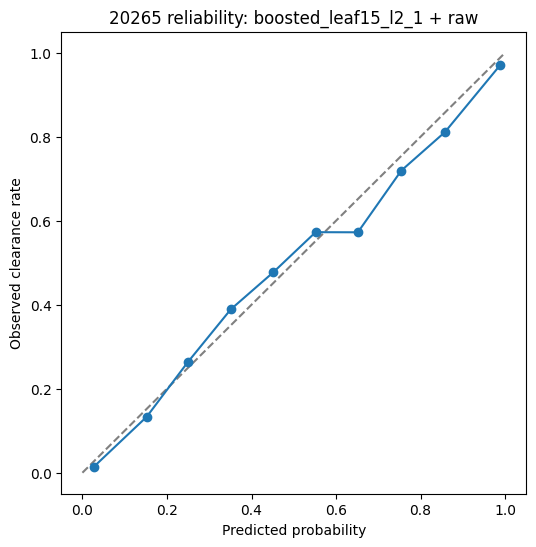

In [5]:
chosen_method = calibration_summary.index[0]
recent = session_samples[VALIDATION_SESSIONS[-1]].copy()
recent['probability'] = recent_predictions[chosen_method]
recent['ratio_band'] = pd.cut(recent['position_to_capacity'], [-np.inf, .05, .10, .20, .30, np.inf])
recent['days_band'] = pd.cut(recent['days_to_deadline'], [-np.inf, 7, 14, 30, 60, np.inf])
recent['probability_band'] = pd.cut(recent['probability'], np.linspace(0, 1, 11), include_lowest=True)

def slice_table(column):
    rows = []
    for label, group in recent.groupby(column, observed=True):
        if len(group) < 100:
            continue
        weight = group['model_weight'].to_numpy()
        predicted = np.average(group['probability'], weights=weight)
        observed = np.average(group['cleared'], weights=weight)
        rows.append({
            column: label, 'rows': len(group), 'predicted': predicted,
            'observed': observed, 'absolute_gap': abs(predicted - observed),
            'brier': brier_score_loss(group['cleared'], group['probability'], sample_weight=weight),
        })
    return pd.DataFrame(rows)

for column in ['probability_band', 'ratio_band', 'days_band', 'campus', 'term']:
    print(column)
    display(slice_table(column))

reliability = slice_table('probability_band')
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], '--', color='gray')
ax.plot(reliability['predicted'], reliability['observed'], marker='o')
ax.set(
    xlabel='Predicted probability', ylabel='Observed clearance rate',
    title=f'{VALIDATION_SESSIONS[-1]} reliability: {chosen_candidate} + {chosen_method}',
)
plt.show()

## 5. Findings and decision

All tuning and calibration comparisons used chronological holdouts and identical deterministic training rows within each fold.

### Tree tuning

- `boosted_leaf15_l2_1` had the lowest four-fold mean Brier at **0.05106**, with **0.01734 mean ECE** and **0.94413 mean ROC AUC**.
- The boosted configurations were practically tied. Mean Brier ranged only from **0.05106** to **0.05111**.
- `boosted_leaf31_l2_1` had the best worst-fold Brier at **0.05503**, while `boosted_leaf7_l2_1` had the best mean ECE at **0.01665**.
- The logistic control remained materially behind at **0.05721 mean Brier**.
- Because L2=1 and L2=3 differed by only **0.000019 mean Brier**, retain the more regularized `boosted_leaf15_l2_3` configuration as the stable downstream control.

### Calibration

- Raw probabilities were best overall at **0.05121 mean Brier**, **0.01716 mean ECE**, and **0.94355 mean ROC AUC**.
- Platt and isotonic calibration improved the newest `20265` fold slightly, but both worsened the earlier folds and the four-fold average.
- No global calibrator is selected. The production candidate should retain raw boosted-tree probabilities.

### Remaining failure slices

- Within seven days of the deadline, the model predicted **53.0%** while **38.7%** met the target, a **14.3-point overprediction**.
- Ranks above 30% of capacity were underpredicted by **3.3 points**.
- Winter offerings were overpredicted by **4.9 points**, and Scarborough offerings by **3.9 points**.
- Probability-band gaps were mixed in direction and reached a maximum of **7.9 points**.

### Decision

Carry the 15-leaf, L2=3 boosted model with raw probabilities into Notebook 5. Notebook 5 should test targeted deadline, rank, term, and campus features against this stable control. It should retain a new feature only when it improves chronological Brier and the relevant failure slice without damaging calibration elsewhere.
